In [1]:
import kagglehub
import pandas as pd  # nao vai usar :(
import numpy as np
from scipy.spatial.distance import cdist
import pyspark.pandas as ps
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, coalesce, lower, regexp_replace, trim, when, length, upper, log1p, udf
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler, StandardScaler, PCA
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [2]:
spark = SparkSession.builder.appName("roblox_games_data_analisys").getOrCreate()

In [3]:
spark.conf.set("spark.sql.ansi.enabled", False)

# Leitura dataset

## Carregar datasets


In [4]:
'''
roblox-games-data - 1/22/2022 to 5/2/2022 *outdated???

info: Date,Active Users,Favorites,Total Visits,Date Created,Last Updated,Server Size,Genre,Title

# Download latest version
roblox_games_data_path = kagglehub.dataset_download("databitio/roblox-games-data")

print("Path to dataset files:", roblox_games_data_path)
'''

'\nroblox-games-data - 1/22/2022 to 5/2/2022 *outdated???\n\ninfo: Date,Active Users,Favorites,Total Visits,Date Created,Last Updated,Server Size,Genre,Title\n\n# Download latest version\nroblox_games_data_path = kagglehub.dataset_download("databitio/roblox-games-data")\n\nprint("Path to dataset files:", roblox_games_data_path)\n'

In [5]:
'''
roblox-games-dataset -  27/10/2024  *newest

info: Rank,Name,Active,Visits,Favorites,Likes,Deslikes,Rating
'''

# Download latest version
roblox_games_path = kagglehub.dataset_download("biggiefats/roblox-games-dataset")

print("Path to dataset files:", roblox_games_path)


100%|██████████| 40.0k/40.0k [00:00<00:00, 1.25MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/biggiefats/roblox-games-dataset/versions/1


In [6]:
'''
roblox-dataset -  11/5/2024

info: Title,Creator,AgeRecomendation,ActivePlayers,Favorites,Visits,VoiceChat,
      Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,Datafetch
'''

# Download latest version
roblox_dataset_path = kagglehub.dataset_download("jansenccruz/roblox-dataset")

print("Path to dataset files:", roblox_dataset_path)

100%|██████████| 1.02M/1.02M [00:01<00:00, 892kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/jansenccruz/roblox-dataset/versions/1


In [7]:
#Load dataframes

path=roblox_dataset_path+"/roblox_games_data.csv"
print(path)
df_old = spark.read.csv(path, header=True, inferSchema=True)

/root/.cache/kagglehub/datasets/jansenccruz/roblox-dataset/versions/1/roblox_games_data.csv


In [8]:
df_old=df_old.withColumnRenamed("Favorites","Favourites")

In [9]:
df_old.show()

+--------------------+--------------------+-----------------+------+----------+-------+-------------+-------------+----------+----------+----------+---------------+-----+--------+--------------------+---------------+
|               Title|             Creator|AgeRecommendation|Active|Favourites| Visits|    VoiceChat|       Camera|   Created|   Updated|ServerSize|          Genre|Likes|Dislikes|            GameLink|    DateFetched|
+--------------------+--------------------+-----------------+------+----------+-------+-------------+-------------+----------+----------+----------+---------------+-----+--------+--------------------+---------------+
|Catalog Avatar Cr...|         @ItsMuneeeb|         All Ages| 19469|   3438844|  2.8B+|    Supported|    Supported|  7/4/2021| 11/5/2024|        24|       Shopping|  1M+|   124K+|https://www.roblo...|11/5/2024 20:24|
| [HALLOWEEN 🎃] T...|            CTStudio|         Ages 13+|  2709|   2911356|988.3M+|    Supported|Not Supported| 1/15/2021| 11/5/2

In [10]:
path=roblox_games_path+"/roblox_games.csv"
print(path)
df_new = spark.read.csv(path, header=True, inferSchema=True)

/root/.cache/kagglehub/datasets/biggiefats/roblox-games-dataset/versions/1/roblox_games.csv


In [11]:
df_new.show()

+----+--------------------+-------+--------------+----------+---------+---------+------+
|Rank|                Name| Active|        Visits|Favourites|    Likes| Dislikes|Rating|
+----+--------------------+-------+--------------+----------+---------+---------+------+
|  #1|         Blox Fruits|483,372|41,346,317,182|13,574,097|8,521,670|  676,846| 92.64|
|  #2|     Brookhaven 🏡RP|474,141|55,635,148,446|22,117,653|6,108,763|  955,845| 86.47|
|  #3| Dress To Impress 💜|297,764| 3,876,511,994| 3,182,036|2,042,092|  188,403| 91.55|
|  #4|    PETS GO! ✨ [NEW]|172,411|   145,691,211|   199,254|  275,267|   20,140| 93.18|
|  #5|    Murder Mystery 2|159,531|18,310,453,247|19,306,585|8,001,198|  786,705| 91.05|
|  #6|[UPDATE 1] Anime ...|142,586|   534,044,793|   578,491|1,592,383|   52,159| 96.83|
|  #7|The Strongest Bat...|142,531| 8,747,773,201| 4,177,434|2,931,689|  565,313| 83.83|
|  #8|Pet Simulator 99! 🎃|131,088| 1,527,851,114| 1,479,726|2,586,908|  106,245| 96.05|
|  #9|          Adopt Me

## Remove Duplicate Rows

In [12]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, desc, col

# For df_old: remove duplicates based on 'Title', keeping the most recent 'DateFetched'
window_old = Window.partitionBy("Title").orderBy(desc("DateFetched"))
df_old = df_old.withColumn("row_num", row_number().over(window_old)).filter(col("row_num") == 1).drop("row_num")

# print("df_old after removing duplicates by Title and keeping most recent DateFetched:")
# df_old.show(5, truncate=False)

In [13]:
df_count = df_old.groupBy("Title").count().orderBy("count", ascending=False)
df_count.show()

+--------------------+-----+
|               Title|count|
+--------------------+-----+
| Anime Catching S...|    1|
|   Gun Armory Tycoon|    1|
| PETS GO! 🍀 [ +1...|    1|
| PETS GO! 🍀 [+1B...|    1|
| Piggy [DECAY CHA...|    1|
| Roblox Spirit Ha...|    1|
| SCP Containment ...|    1|
|    Sol's RNG [Eon1]|    1|
|   Sol's RNG [Era 9]|    1|
| Sonic Evocative:...|    1|
| Sonic.EXE: The D...|    1|
| Sonic.EXE: The d...|    1|
|        Strict Mom👿|    1|
| [ BUMBAA  + 16 ]...|    1|
| [ DIVA + 15] TOD 🎃|    1|
| [ 😇 ]GnomeCode'...|    1|
| [Fixed] Sonic Ev...|    1|
| [HALLOWEEN 🎃] T...|    1|
| [Modded TITANIC]...|    1|
| [RETURN] Z O th ...|    1|
+--------------------+-----+
only showing top 20 rows


In [14]:
# For df_new: remove duplicates based on 'Name', keeping the one with the most 'Visits'
window_new = Window.partitionBy("Name").orderBy(desc("Visits"))
df_new = df_new.withColumn("row_num", row_number().over(window_new)).filter(col("row_num") == 1).drop("row_num")

# print("\ndf_new after removing duplicates by Name and keeping most Visits:")
# df_new.show(5, truncate=False)

In [15]:
df_count = df_new.groupBy("Name").count().orderBy("count", ascending=False)
df_count.show()

+--------------------+-----+
|                Name|count|
+--------------------+-----+
|   Gun Armory Tycoon|    1|
| Michael's Zombie...|    1|
| Piggy [DECAY CHA...|    1|
|   Sol's RNG [Era 9]|    1|
| Sonic.EXE: The d...|    1|
| [ 🎃 HALLOWEEN ]...|    1|
| [HALLOWEEN 🎃] T...|    1|
|     🔥 Dragon Blox |    1|
|        🚁 My Prison|    1|
|(HALLOWEEN EVENT,...|    1|
|(HALLOWEEN) Inter...|    1|
|(UPDATE 7) King L...|    1|
|(🎃Halloween🎃) L...|    1|
|(📱 PHONES, MINIM...|    1|
|(🔪UPDATE🔪) Tha ...|    1|
|+1 Blocks Every S...|    1|
|+1 Fat Every Seco...|    1|
|         1% Win Obby|    1|
|2 Player Sushi Ty...|    1|
|3-2-1 Blast Off S...|    1|
+--------------------+-----+
only showing top 20 rows


## Normalização dos nomes

In [16]:

EVENT_REGEX = (
    r"(?i)\b("
    r"new\s+update|big\s+update|mega\s+update|huge\s+update|balance\s+update|bug\s+fixes?|"
    r"update|upd|release|revamp|rework|patch|"
    r"halloween|christmas|xmas|winter|summer|spring|easter|valentine'?s?|thanksgiving|"
    r"black\s+friday|april\s+fools?|new\s+year|lunar\s+new\s+year|"
    r"free\s+ugc|ugc|limited\s+time|limited|new\s+codes?|codes?|code|rewards?|giveaway|"
    r"live\s+event|event|"
    r"new\s+map|new\s+world|new\s+area|new\s+island|new\s+pets?|new\s+eggs?|new\s+boss|"
    r"new\s+raid|new\s+weapons?|new\s+skins?|new\s+units?|new\s+fruit|new\s+quest|new\s+mode|"
    r"beta|alpha|demo|testing|early\s+access|open\s+beta|closed\s+beta"
    r")\b"
)

normalized_column_name="Normalized_name"

def criar_nome_normalizado(df, coluna_nome="Name"):
    return (
        df
        .withColumn(normalized_column_name, lower(col(coluna_nome)))

        # Remove emojis e símbolos estranhos
        .withColumn(
            normalized_column_name,
            regexp_replace(col(normalized_column_name), r"[^\w\s\-\:\|\!\(\)\[\]&']", " ")
        )

        # Remove blocos como [UPDATE], (HALLOWEEN), [NEW CODES]
        .withColumn(
            normalized_column_name,
            regexp_replace(
                col(normalized_column_name),
                r"(?i)[\[\(]\s*[^)\]]*(update|upd|event|codes?|ugc|halloween|christmas|xmas|easter|winter|summer|beta|alpha)[^)\]]*[\]\)]",
                " "
            )
        )

        # Remove palavras de evento/update
        .withColumn(
            normalized_column_name,
            regexp_replace(col(normalized_column_name), EVENT_REGEX, " ")
        )

        # Padroniza e limpa separadores
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"&", " and "))
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"[\[\]\(\)\|:!\-]", " "))
        .withColumn(normalized_column_name, regexp_replace(col(normalized_column_name), r"\s+", " "))
        .withColumn(normalized_column_name, trim(col(normalized_column_name)))

        # Se o resultado ficar vazio, volta para o nome original em lowercase
        .withColumn(
            normalized_column_name,
            when(length(col(normalized_column_name)) > 0, col(normalized_column_name))
            .otherwise(lower(col(coluna_nome)))
        )
    )

In [17]:
df_old = criar_nome_normalizado(df_old,coluna_nome="Title")
#df_old.show()

In [18]:
df_new = criar_nome_normalizado(df_new,coluna_nome="Name")
#df_new.show()

## Correção colunas numericas

In [19]:
def correct_number_columns(col_name, num_type="bigint"):
    """
    Converts numeric string columns like:
    12K+ -> 12000
    1.5M -> 1500000
    2B   -> 2000000000
    950+ -> 950
    300  -> 300
    Handles commas in numbers.
    """

    c = upper(trim(col(col_name)))

    # Remove '+' wherever it appears, as it's not part of the number we want to cast
    c = regexp_replace(c, r"\+", "")

    # Remove commas from numbers (e.g., "483,372" -> "483372")
    c = regexp_replace(c, r",", "")

    # Extract only the numeric part and cast to DoubleType to handle decimals
    number = regexp_replace(c, r"[KMB]", "").cast(DoubleType())

    result = (
        when(c.rlike(r"K$"), number * 1000)
        .when(c.rlike(r"M$"), number * 1000000)
        .when(c.rlike(r"B$"), number * 1000000000)
        .otherwise(number)
        .cast(num_type) # Final cast to the desired integer type
    )

    return result

### Df_old

In [20]:
df_old = df_old.withColumn("Likes", correct_number_columns("Likes", "bigint"))
df_old = df_old.withColumn("Dislikes", correct_number_columns("Dislikes", "bigint"))
df_old = df_old.withColumn("Active", correct_number_columns("Active", "int"))
df_old = df_old.withColumn("Favourites", correct_number_columns("Favourites", "bigint"))
df_old = df_old.withColumn("Visits", correct_number_columns("Visits", "bigint"))

### Df_new

In [21]:
df_new=df_new.drop("Rank")
df_new=df_new.drop("Rating")

In [22]:
df_new=df_new.withColumn("Active",correct_number_columns("Active","int"))
df_new=df_new.withColumn("Visits",correct_number_columns("Visits","bigint"))
df_new=df_new.withColumn("Favourites",correct_number_columns("Favourites","bigint"))
df_new=df_new.withColumn("Likes",correct_number_columns("Likes","bigint"))
df_new=df_new.withColumn("Dislikes",correct_number_columns("Dislikes","bigint"))

In [23]:
cols_update = ["Visits", "Likes", "Dislikes", "Favourites", "Active"]

In [24]:
df_new_update = df_new.select("Normalized_name",
        *[col(c).alias(f"{c}_new")
        for c in cols_update
        if c in df_new.columns]
)

## Juntar dataframes

In [25]:
df_join = df_old.join(df_new_update, on="Normalized_name", how="left")

In [26]:
for c in cols_update:
    new_col = f"{c}_new"

    if c in df_join.columns and new_col in df_join.columns:
        df_join = df_join.withColumn(
            c,
            coalesce(col(new_col), col(c))
        )

In [27]:
df_final = df_join.drop(
    *[
        f"{c}_new"
        for c in cols_update
        if f"{c}_new" in df_join.columns
    ]
)

In [28]:
df_final.show()

+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+----------+----------+----------+-------------+-------+--------+--------------------+----------------+
|     Normalized_name|               Title|             Creator|AgeRecommendation|Active|Favourites|     Visits|    VoiceChat|       Camera|   Created|   Updated|ServerSize|        Genre|  Likes|Dislikes|            GameLink|     DateFetched|
+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+----------+----------+----------+-------------+-------+--------+--------------------+----------------+
|anime catching si...| Anime Catching S...|           BestBunny|         All Ages|   206|    191886|   79300000|Not Supported|Not Supported| 1/13/2023| 8/15/2024|        12|   Simulation| 285000|   12000|https://www.roblo...| 11/9/2024 23:52|
|   gun armory tycoon|   Gun

In [29]:
#df_final.printSchema()

# Analise inicial

## Ajustes (selecionar colunas numericas)

In [30]:
df=df_final

In [31]:
#df.printSchema()

In [32]:
numeric_types = ["int", "bigint", "double", "float", "decimal", "long", "short"]

numeric_columns = [
    col_name
    for col_name, dtype in df.dtypes
    if dtype in numeric_types or dtype.startswith("decimal")
]
numeric_columns.append("Title")
numeric_columns.append("Genre")

In [33]:
df_num=df.select(numeric_columns)

In [34]:
#df_num.show()

In [35]:
df_num=df_num.pandas_api()

In [36]:
#df_num.head()

## Valores Nan/Null

In [37]:
cols=df_num.columns

In [38]:
for i in cols:
    print(i,df_num[i].isna().sum())
    print(i,df_num[i].isnull().sum())
    df_na=df_num[df_num[i]=="N/A"]
    print(f"{i} nan_string {df_na[i].count()}")


Active 0
Active 0
Active nan_string 0
Favourites 0
Favourites 0
Favourites nan_string 0
Visits 0
Visits 0
Visits nan_string 0
ServerSize 0
ServerSize 0
ServerSize nan_string 0
Likes 0
Likes 0
Likes nan_string 0
Dislikes 0
Dislikes 0
Dislikes nan_string 0
Title 0
Title 0
Title nan_string 0
Genre 0
Genre 0
Genre nan_string 487


## Analises

In [39]:
df_final.show()

+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+----------+----------+----------+-------------+-------+--------+--------------------+----------------+
|     Normalized_name|               Title|             Creator|AgeRecommendation|Active|Favourites|     Visits|    VoiceChat|       Camera|   Created|   Updated|ServerSize|        Genre|  Likes|Dislikes|            GameLink|     DateFetched|
+--------------------+--------------------+--------------------+-----------------+------+----------+-----------+-------------+-------------+----------+----------+----------+-------------+-------+--------+--------------------+----------------+
|anime catching si...| Anime Catching S...|           BestBunny|         All Ages|   206|    191886|   79300000|Not Supported|Not Supported| 1/13/2023| 8/15/2024|        12|   Simulation| 285000|   12000|https://www.roblo...| 11/9/2024 23:52|
|   gun armory tycoon|   Gun

In [40]:
df_final.printSchema()

root
 |-- Normalized_name: string (nullable = true)
 |-- Title: string (nullable = true)
 |-- Creator: string (nullable = true)
 |-- AgeRecommendation: string (nullable = true)
 |-- Active: integer (nullable = true)
 |-- Favourites: long (nullable = true)
 |-- Visits: long (nullable = true)
 |-- VoiceChat: string (nullable = true)
 |-- Camera: string (nullable = true)
 |-- Created: string (nullable = true)
 |-- Updated: string (nullable = true)
 |-- ServerSize: integer (nullable = true)
 |-- Genre: string (nullable = true)
 |-- Likes: long (nullable = true)
 |-- Dislikes: long (nullable = true)
 |-- GameLink: string (nullable = true)
 |-- DateFetched: string (nullable = true)



In [41]:
num_cols=cols.drop("Title")
num_cols=num_cols.drop("Genre")

In [42]:
df_num.head()

,Active,Favourites,Visits,ServerSize,Likes,Dislikes,Title,Genre
0,206,191886,79300000,12,285000,12000,Anime Catching Simulator,Simulation
1,1006,55544,32066588,8,46677,3736,Gun Armory Tycoon,Simulation
2,4281,1521,546300,10,1207,94,PETS GO! 🍀 [ +1B LUCK],N/A
3,1939,685,227800,10,588,42,PETS GO! 🍀 [+1B LUCK],N/A
4,27466,11669525,13110395425,6,3615821,406011,Piggy [DECAY CHAPTER],Survival


In [43]:
df_num.describe()

,Active,Favourites,Visits,ServerSize,Likes,Dislikes
count,1534.000000,1.534000e+03,1.534000e+03,1534.000000,1.534000e+03,1.534000e+03
mean,4231.408735,9.806732e+05,4.501113e+08,25.663625,2.354806e+05,3.129972e+04
std,22273.500075,2.630438e+06,2.414365e+09,29.441246,7.088276e+05,9.274837e+04
min,0.000000,0.000000e+00,0.000000e+00,1.000000,0.000000e+00,0.000000e+00
25%,86.000000,7.506000e+03,1.400000e+06,10.000000,1.093000e+03,3.640000e+02
50%,804.000000,1.116010e+05,2.519544e+07,18.000000,2.300000e+04,3.757000e+03
75%,1924.000000,7.315230e+05,1.847692e+08,32.000000,1.400000e+05,2.153600e+04
max,483372.000000,2.873764e+07,5.563515e+10,700.000000,8.521670e+06,1.441230e+06


### Distribuições

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


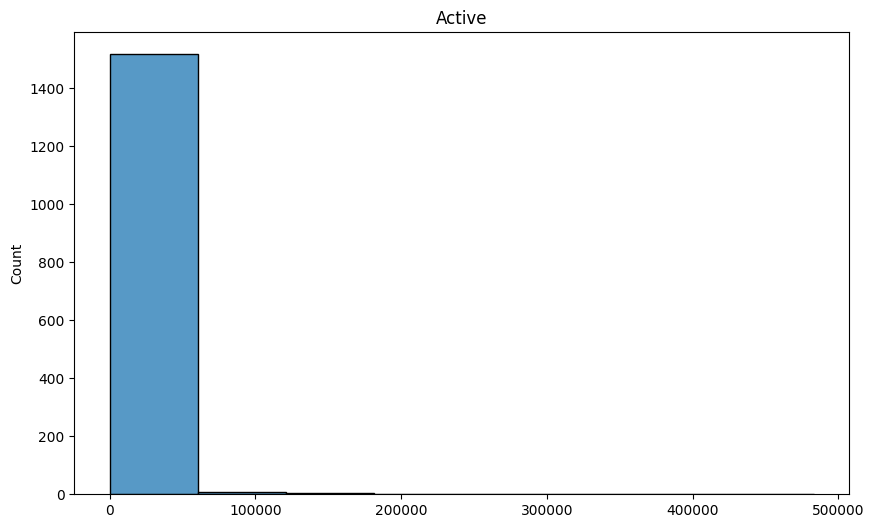

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


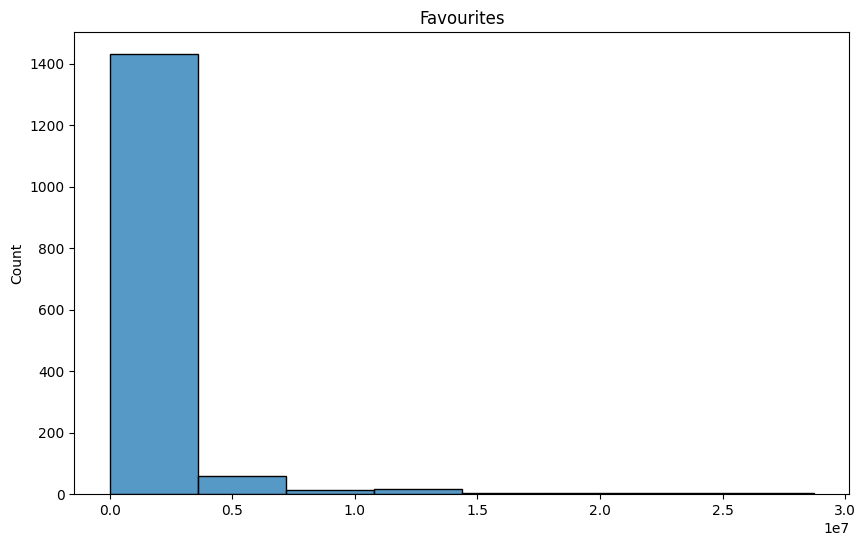

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


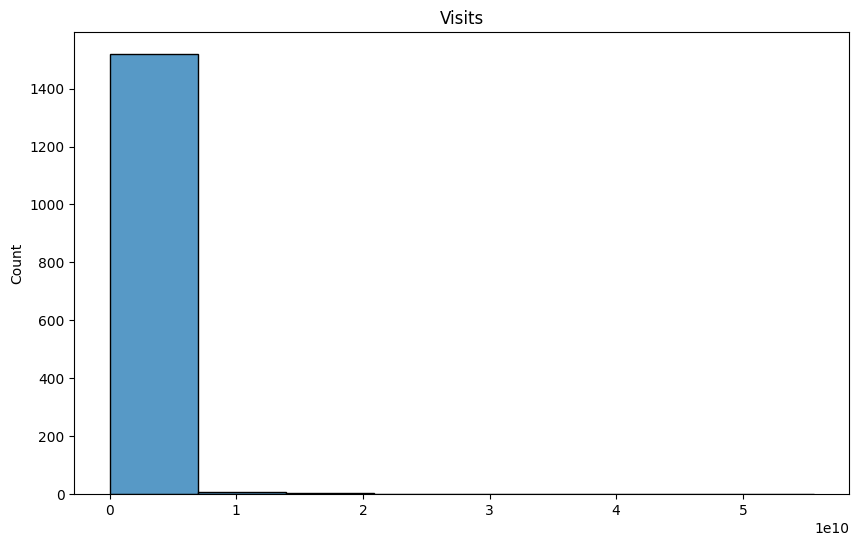

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


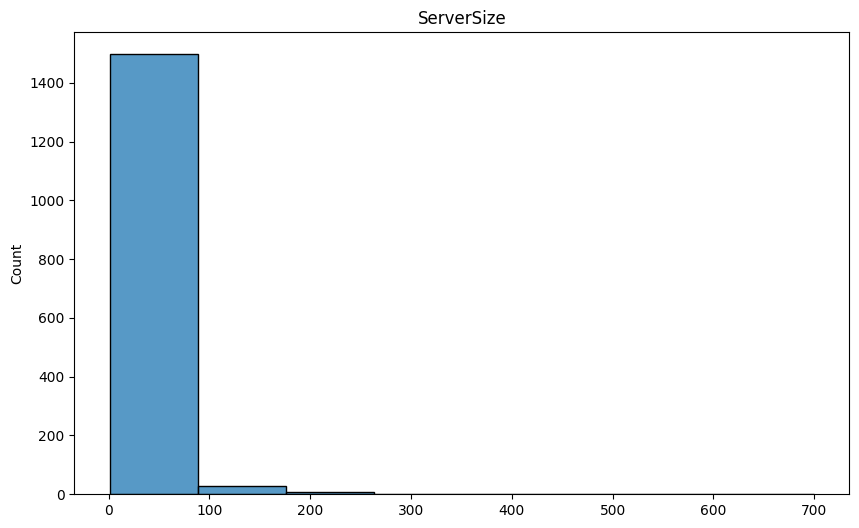

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


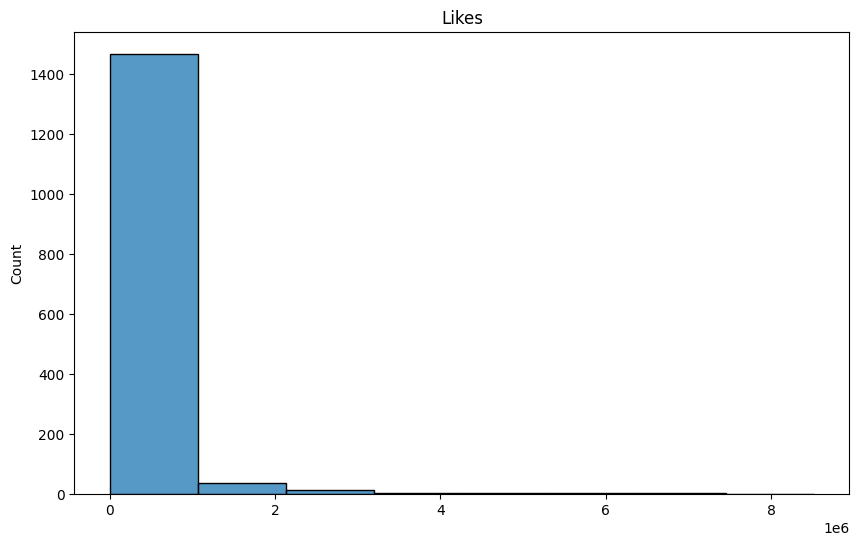

/usr/local/lib/python3.12/dist-packages/pyspark/pandas/utils.py:1037: PandasAPIOnSparkAdviceWarning: `to_numpy` loads all data into the driver's memory. It should only be used if the resulting NumPy ndarray is expected to be small.
  warnings.warn(message, PandasAPIOnSparkAdviceWarning)


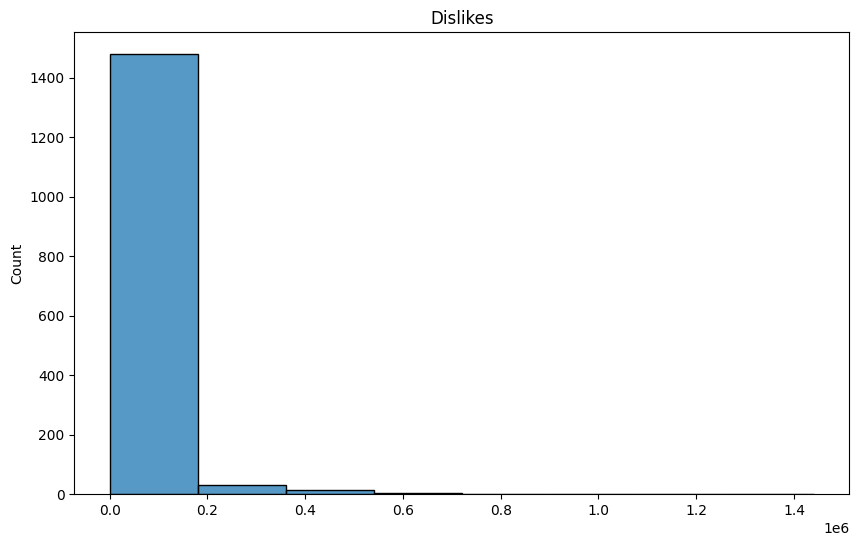

In [44]:

for i in num_cols:
  plt.figure(figsize=(10, 6))
  plt.title(i)
  sns.histplot(df_num[i].to_numpy(), bins=8)
  plt.show()

### Data criação jogos com genero Nan

In [45]:
p_df=df_final.toPandas()

In [46]:
p_df["Created"] = pd.to_datetime(p_df["Created"], errors="coerce")

In [47]:
p_df["Genre"] = p_df["Genre"].replace(
    "N/A",
    np.nan
)

In [48]:
df_genre_nan = p_df[p_df["Genre"].isna()]

In [49]:
df_genre_nan.head()

,Normalized_name,Title,Creator,AgeRecommendation,Active,Favourites,Visits,VoiceChat,Camera,Created,Updated,ServerSize,Genre,Likes,Dislikes,GameLink,DateFetched
2,pets go 1b luck,PETS GO! 🍀 [ +1B LUCK],BK Games Uploading 3,All Ages,4281,1521,546300,Supported,Supported,2024-10-28,11/6/2024,10,NaN,1207,94,https://www.roblox.com/games/89998149942357/PE...,11/6/2024 22:35
3,pets go 1b luck,PETS GO! 🍀 [+1B LUCK],BK Games Uploading 3,All Ages,1939,685,227800,Supported,Supported,2024-10-28,11/5/2024,10,NaN,588,42,https://www.roblox.com/games/89998149942357/PE...,11/5/2024 21:17
6,scp containment breach part 4 working scp's,SCP Containment Breach - Part 4! (Working SCP...,@joshman901,All Ages,6,27872,11600000,Not Supported,Not Supported,2018-05-12,11/10/2022,6,NaN,4409,1207,https://www.roblox.com/games/1754152319/SCP-Co...,11/5/2024 21:37
15,gnomecode's tower defence new,[ 😇 ]GnomeCode's Tower Defence Beta New!,@noob_YT2823,All Ages,0,3,722,Not Supported,Supported,2024-08-03,9/10/2024,25,NaN,6,3,https://www.roblox.com/games/18778322468/Gnome...,11/5/2024 21:13
18,modded titanic pet simulator z x ps 99,[Modded TITANIC] ❄ Pet Simulator Z x PS 99,@buildZgame5,All Ages,30,10507,206100,Supported,Supported,2024-09-23,11/6/2024,10,NaN,109,66,https://www.roblox.com/games/79780711010428/Mo...,11/6/2024 22:24


In [50]:
df_genre_nan["Created"].describe()

,Created
count,487
mean,2023-10-01 19:36:50.266940416
min,2010-06-14 00:00:00
25%,2023-06-25 00:00:00
50%,2024-06-29 00:00:00
75%,2024-09-29 00:00:00
max,2024-11-03 00:00:00


In [51]:
com_genero = p_df[p_df["Genre"].notna()]
com_genero["Created"].describe()

,Created
count,1047
mean,2022-02-05 00:15:07.736389632
min,2008-03-29 00:00:00
25%,2021-01-28 00:00:00
50%,2022-11-19 00:00:00
75%,2023-12-17 12:00:00
max,2024-09-20 00:00:00


In [52]:
sem_genero = p_df[p_df["Genre"].isna()]
com_genero = p_df[p_df["Genre"].notna()]

print("Jogos sem gênero:")
print("Quantidade:", len(sem_genero))
print("Data mínima:", sem_genero["Created"].min())
print("Data média:", sem_genero["Created"].mean())
print("Data mediana:", sem_genero["Created"].median())
print("Data máxima:", sem_genero["Created"].max())

print("\nJogos com gênero:")
print("Quantidade:", len(com_genero))
print("Data mínima:", com_genero["Created"].min())
print("Data média:", com_genero["Created"].mean())
print("Data mediana:", com_genero["Created"].median())
print("Data máxima:", com_genero["Created"].max())

Jogos sem gênero:
Quantidade: 487
Data mínima: 2010-06-14 00:00:00
Data média: 2023-10-01 19:36:50.266940416
Data mediana: 2024-06-29 00:00:00
Data máxima: 2024-11-03 00:00:00

Jogos com gênero:
Quantidade: 1047
Data mínima: 2008-03-29 00:00:00
Data média: 2022-02-05 00:15:07.736389632
Data mediana: 2022-11-19 00:00:00
Data máxima: 2024-09-20 00:00:00


### Avaliação por genero

In [53]:
genres=p_df["Genre"].unique()

In [54]:
p_df_plot = p_df.copy()
p_df_plot = p_df_plot[p_df_plot["Genre"].notna()]

In [55]:
genres = sorted(p_df_plot["Genre"].dropna().unique())

cmap = plt.get_cmap("tab20")

genre_colors = {
    genre: cmap(i / max(len(genres) - 1, 1))
    for i, genre in enumerate(genres)
}

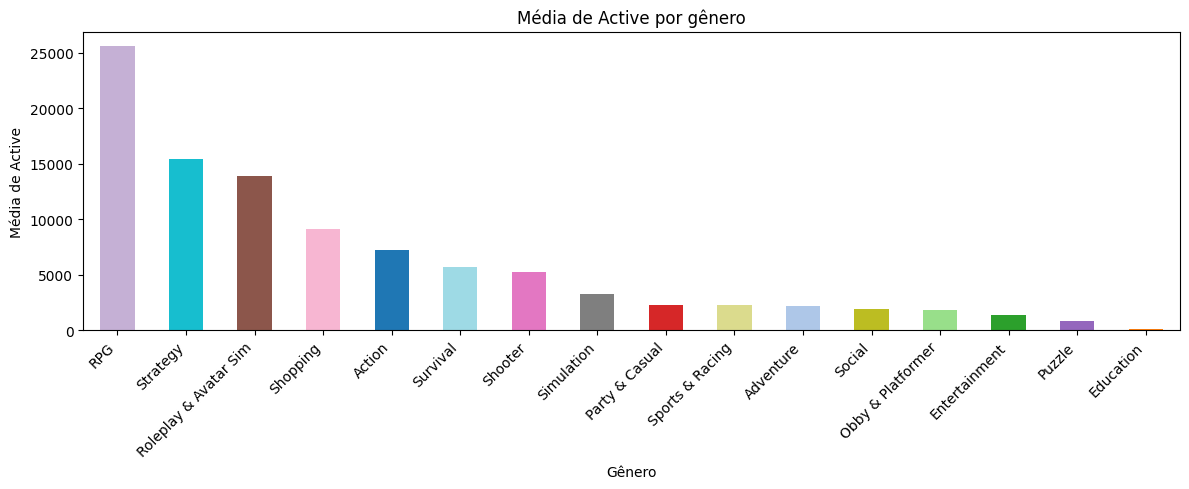

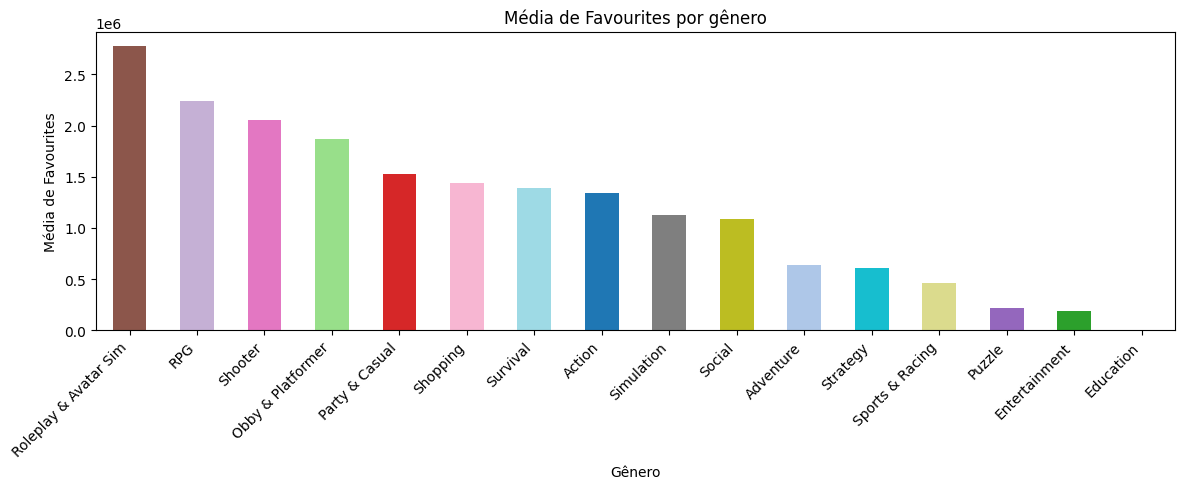

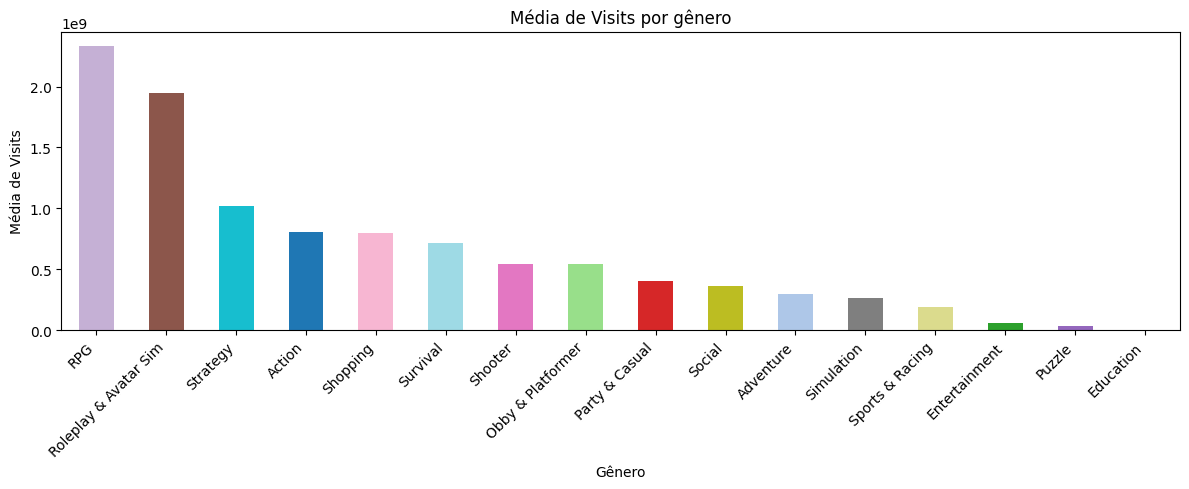

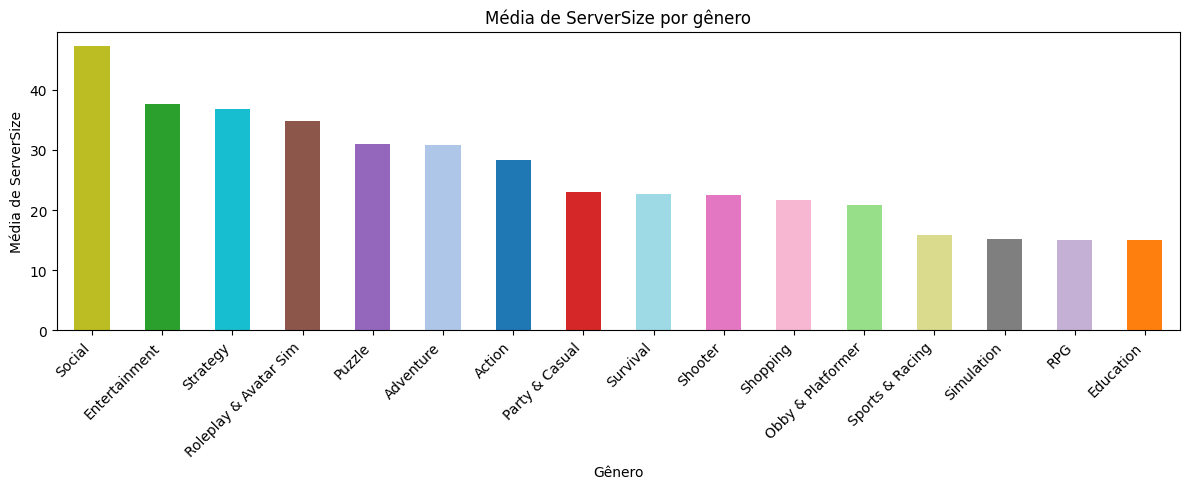

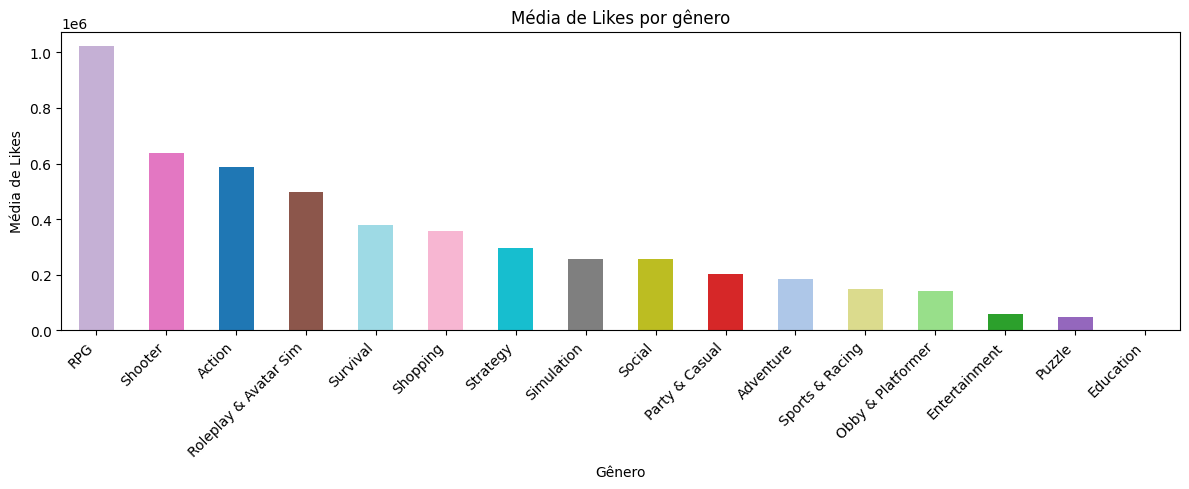

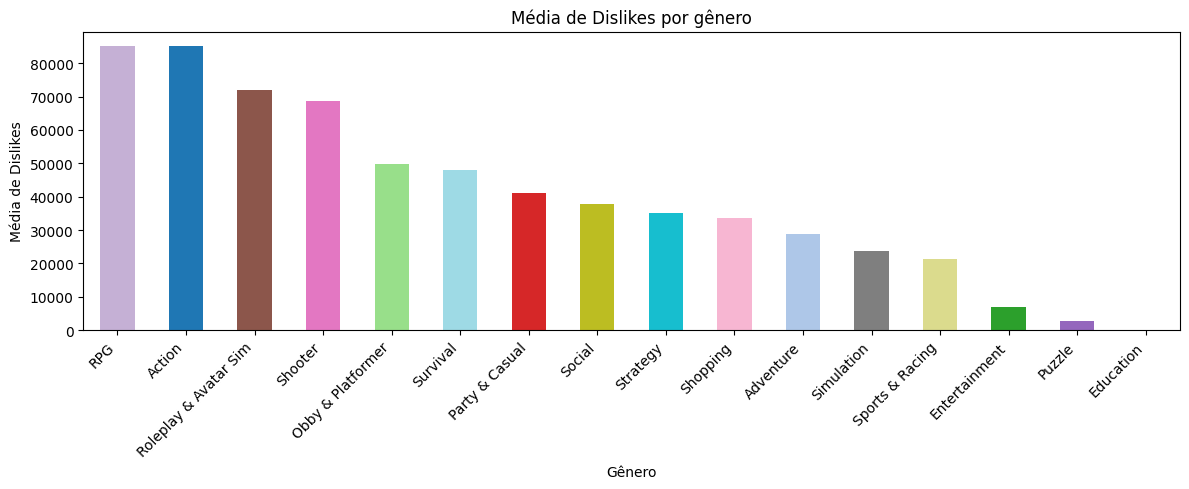

In [56]:
for col in num_cols:
    medias = (
        p_df_plot
        .groupby("Genre")[col]
        .mean()
        .sort_values(ascending=False)
    )

    colors = [genre_colors[genre] for genre in medias.index]

    plt.figure(figsize=(12, 5))
    medias.plot(kind="bar", color=colors)

    plt.title(f"Média de {col} por gênero")
    plt.xlabel("Gênero")
    plt.ylabel(f"Média de {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

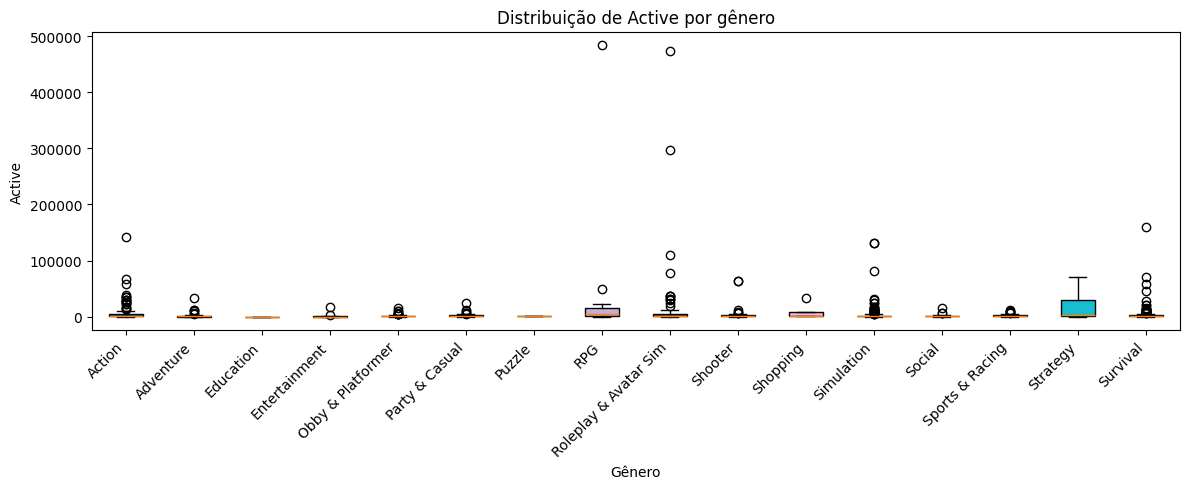

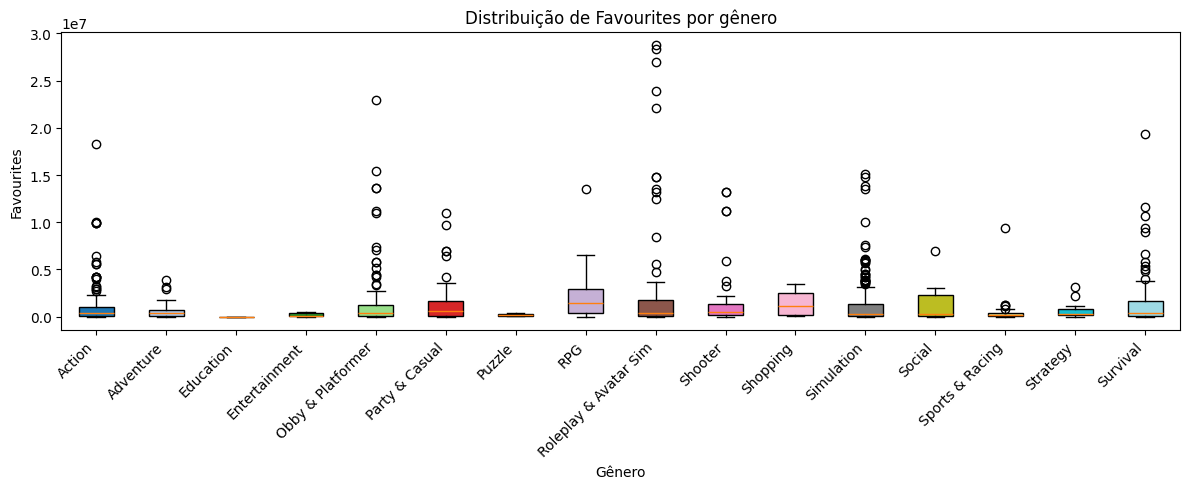

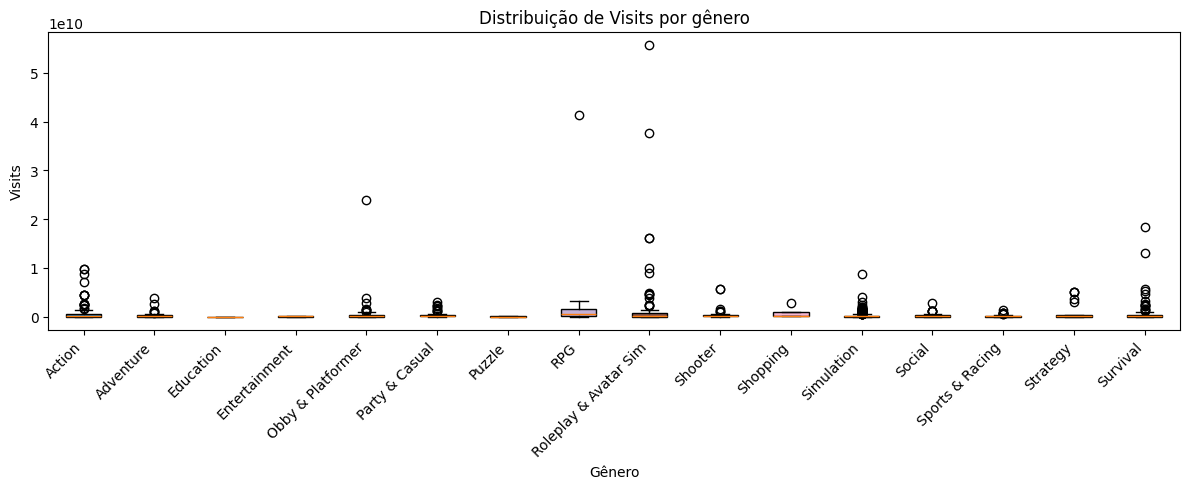

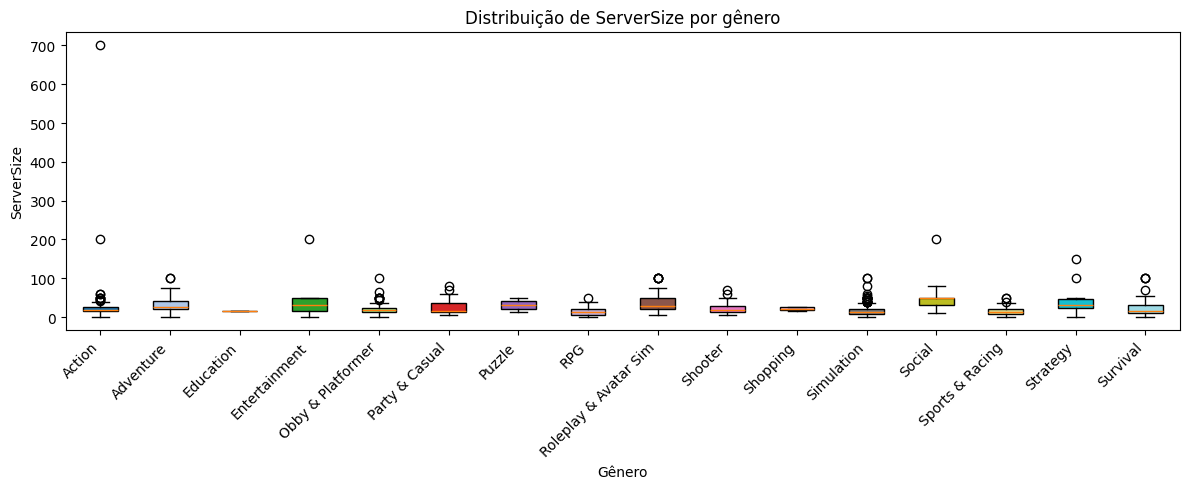

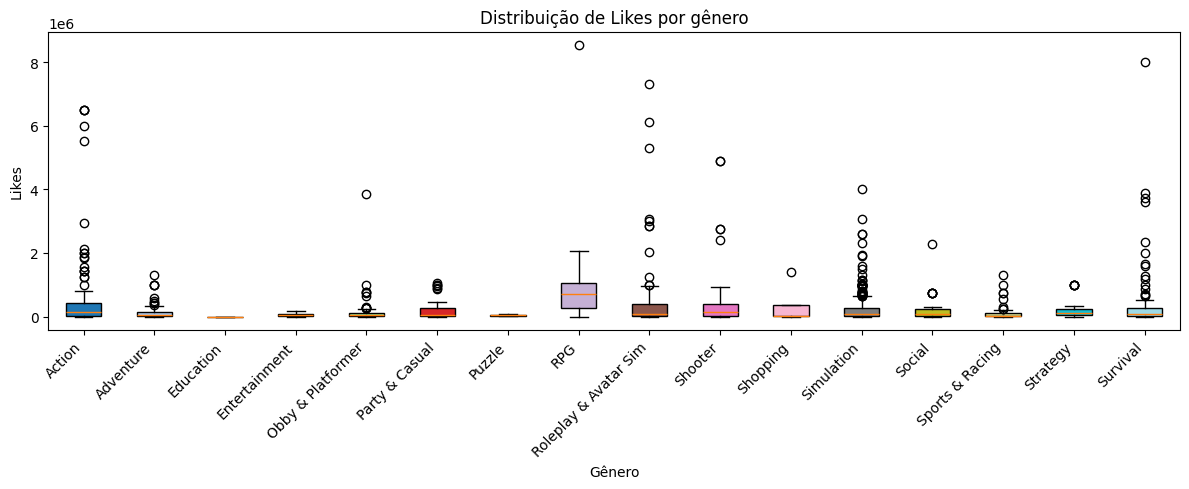

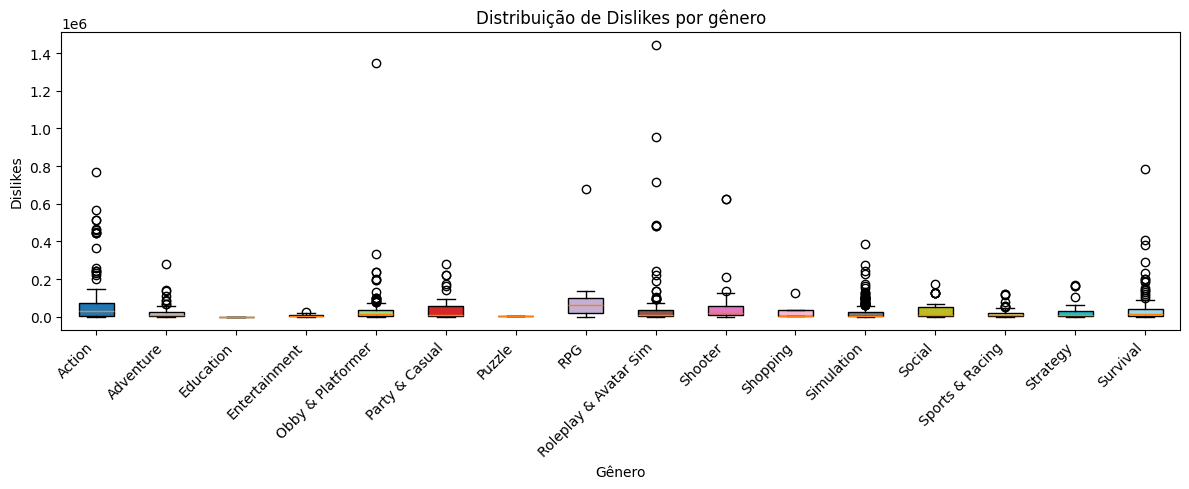

In [57]:
for col in num_cols:
    data = []
    labels = []

    for genre in genres:
        values = p_df_plot.loc[p_df_plot["Genre"] == genre, col].dropna()
        if len(values) > 0:
            data.append(values)
            labels.append(genre)

    plt.figure(figsize=(12, 5))

    box = plt.boxplot(
        data,
        tick_labels=labels,
        patch_artist=True
    )

    for patch, genre in zip(box["boxes"], labels):
        patch.set_facecolor(genre_colors[genre])

    plt.title(f"Distribuição de {col} por gênero")
    plt.xlabel("Gênero")
    plt.ylabel(col)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# PCA

### Transformando amostras

In [61]:
from pyspark.sql.functions import log1p, col

df_pca = df_final

cols_log = ["Active", "Visits", "Favourites", "Likes", "Dislikes"]
cols_sem_log = ["ServerSize"]

# Criar versões em log das colunas de contagem
for c in cols_log:
    df_pca = df_pca.withColumn(f"log_{c}", log1p(col(c).cast("double")))

# Converter ServerSize para double
df_pca = df_pca.withColumn("ServerSize", col("ServerSize").cast("double"))

In [62]:
features_cols = [f"log_{c}" for c in cols_log] + cols_sem_log

assembler = VectorAssembler(
    inputCols=features_cols,
    outputCol="features_raw",
    handleInvalid="skip"
)

df_vector = assembler.transform(df_pca)

In [63]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

### Aplicação PCA

In [64]:
pca = PCA(
    k=3,
    inputCol="features_scaled",
    outputCol="pca_features"
)

pca_model = pca.fit(df_scaled)
df_pca_result = pca_model.transform(df_scaled)

In [65]:
pca_model.explainedVariance

DenseVector([0.764, 0.162, 0.0429])

In [66]:
pc_matrix = pca_model.pc.toArray()

loadings = pd.DataFrame(
    pc_matrix,
    index=features_cols,
    columns=[f"PC{i+1}" for i in range(pc_matrix.shape[1])]
)

loadings

,PC1,PC2,PC3
log_Active,-0.414934,0.022038,0.902571
log_Visits,-0.455157,-0.056848,-0.165338
log_Favourites,-0.447658,-0.040177,-0.143003
log_Likes,-0.454567,-0.061713,-0.199748
log_Dislikes,-0.452616,-0.066839,-0.305001
ServerSize,0.093661,-0.993173,0.068214


In [67]:
# Separar o vetor pca_features em duas colunas: PC1 e PC2
get_pc1 = udf(lambda v: float(v[0]), DoubleType())
get_pc2 = udf(lambda v: float(v[1]), DoubleType())

df_pca_plot = (
    df_pca_result
    .withColumn("PC1", get_pc1(col("pca_features")))
    .withColumn("PC2", get_pc2(col("pca_features")))
    .select("Title", "Genre", "PC1", "PC2")
)

pdf_pca = df_pca_plot.toPandas()

In [68]:
fig = px.scatter(
    pdf_pca,
    x="PC1",
    y="PC2",
    color="Genre",
    hover_name="Title",
    hover_data={
        "Genre": True,
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    title="PCA dos jogos do Roblox por gênero"
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title="Gênero"
)

fig.show()

In [69]:
plot_pca_spark = (
    df_pca_result
    .withColumn("PC1", get_pc1(col("pca_features")))
    .withColumn("PC2", get_pc2(col("pca_features")))
    .select("Title", "Genre","Active","Visits","Favourites","Likes","Dislikes","ServerSize","PC1","PC2")
)

plot_pca = plot_pca_spark.toPandas()

fig = px.scatter(
    plot_pca,
    x="PC1",
    y="PC2",
    color="Genre",
    hover_name="Title",
    hover_data={
        "Genre": True,
        "Active": True,
        "Visits": True,
        "Favourites": True,
        "Likes": True,
        "Dislikes": True,
        "ServerSize": True,
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    title="PCA dos jogos do Roblox por gênero"
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title="Gênero"
)

fig.show()

# Clustering

## K-Means

In [74]:
kmeans = KMeans(
    k=3,
    seed=42,
    featuresCol="features_scaled",
    predictionCol="cluster_kmeans"
)

kmeans_model = kmeans.fit(df_scaled)

df_cluster = kmeans_model.transform(df_scaled)

In [75]:
resultados_k = []

for k in range(2, 9):
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="features_scaled",
        predictionCol="cluster_kmeans"
    )

    model = kmeans.fit(df_scaled)
    predictions = model.transform(df_scaled)
    silhouette = evaluator.evaluate(predictions)

    resultados_k.append((k, silhouette))
    print(f"k={k} | silhouette={silhouette:.4f}")

k=2 | silhouette=0.7128
k=3 | silhouette=0.7247
k=4 | silhouette=0.4381
k=5 | silhouette=0.5587
k=6 | silhouette=0.4711
k=7 | silhouette=0.4260
k=8 | silhouette=0.3519


In [76]:
evaluator = ClusteringEvaluator(
    featuresCol="features_scaled",
    predictionCol="cluster_kmeans",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette = evaluator.evaluate(df_cluster)

In [77]:
df_cluster_pca = (
    kmeans_model.transform(df_pca_result)
    .withColumn("PC1", get_pc1(col("pca_features")))
    .withColumn("PC2", get_pc2(col("pca_features")))
    .select(
        "Title",
        "Genre",
        "PC1",
        "PC2",
        "cluster_kmeans",
        "Active",
        "Visits",
        "Likes",
        "Dislikes",
        "Favourites",
        "ServerSize"
    )
)

In [78]:
pdf_cluster_pca = df_cluster_pca.toPandas()

In [79]:
pdf_cluster_pca["cluster_kmeans"] = pdf_cluster_pca["cluster_kmeans"].astype(str)

fig = px.scatter(
    pdf_cluster_pca,
    x="PC1",
    y="PC2",
    color="cluster_kmeans",
    hover_name="Title",
    hover_data={
        "Genre": True,
        "Active": True,
        "Visits": True,
        "Likes": True,
        "Dislikes": True,
        "Favourites": True,
        "ServerSize": True,
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    title="Clusters dos jogos do Roblox visualizados no PCA"
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title="Cluster"
)

fig.show()

## C-Fuzzy

### Código

In [80]:
def generate_random_relevence(X,k,seed=10):

    '''
    Atribui a cada item uma relevância aleatória para cada grupo k.
    Garante que a soma de cada linha seja 1.
    '''

    np.random.seed(seed)
    relevences=[]

    for i in range(len(X)):
        relevences.append([])
        aux=0
        sum=0

        for j in range(k):
            relevences[i].append(np.random.uniform(0,1-aux))
            aux+=relevences[i][j]
            sum+=relevences[i][j]

        if sum!=1:
            relevences[i][0]=1-sum+relevences[i][0]

    return np.array(relevences)


def pertinencias(X, C, m):
    '''
    X: matriz de amostras
    C: matriz de centróides
    m: parâmetro de fuzziness

    Calcula a pertinência w_ij de xi ao centróide C[j]
    usando cdist para calcular as distâncias euclidianas.
    '''

    # cdist é de matrizes 2D, então fiz o reshape xi para (1, n_features)
    # ai da um o array do shape com a distancia de xi pro centroide

    U=[]

    distancias = cdist(X, C, metric='euclidean')

    exponent = 2 / (m - 1)

    for i in distancias:
        aux_U=[]

        for dist_j in i:
            sum = 0

            for dist_l in i:

                if dist_l == 0:
                    sum+=(1.0 if dist_l == dist_j else 0.0)
                else:
                    sum += (dist_j / dist_l)**exponent

            aux_U.append(1 / sum)

        U.append(aux_U)

    return np.array(U)


def centroid_update(X, U, m):

    k = U.shape[1]
    C = []

    for j in range(k):
        numerador = 0
        denominador = 0

        for i in range(len(X)):
            numerador += (U[i][j]) * X[i]
            denominador += U[i][j]

        C.append(numerador/denominador)

    return np.array(C)


def objective_function(X,C,U):

    '''
    X: matriz de dados
    C: matriz de centróides
    U: matriz de pertinência
    Calcula a função objetivo do FCM
    '''

    n_samples = X.shape[0]
    n_clusters = C.shape[0]
    J = 0

    for i in range(n_samples):
        for j in range(n_clusters):
            u_ij = U[i, j]
            J += (u_ij) * (np.linalg.norm(X[i] - C[j]) ** 2)

    return J

In [81]:
def fuzzy_cmeans(X, k, m, max_iter=100, conv = 0.001):

    n_samples = X.shape[0] #n° de linhas

    J_history = []

    U = generate_random_relevence(X, k) #cria a matriz de pertinência aleatória inicial

    C=centroid_update(X, U, m) #inicializa a matriz de centróides

    for iteration in range(max_iter):
        C_old = C.copy()

        U=pertinencias(X, C, m)
        C = centroid_update(X, U, m)
        J = objective_function(X, C, U)


        J_history.append(J)
        convergence = np.linalg.norm(C - C_old)

        if convergence < conv:
            print(f"Convergiu na iteração {iteration}")
            break

        labels = np.argmax(U, axis=1)


    return U, C, labels, J_history


### Aplicando

In [82]:
p_df_fcm = df_scaled.select(
    "Title",
    "Genre",
    "features_scaled"
).toPandas()

In [83]:
X_fcm = np.vstack(
    p_df_fcm["features_scaled"].apply(lambda v: v.toArray())
)

In [96]:
U, C, labels, J_history = fuzzy_cmeans(X_fcm,k=3,m=2,)

Convergiu na iteração 55


In [97]:
p_df_fcm["cluster_fuzzy"] = labels
p_df_fcm["max_pertinencia"] = U.max(axis=1)

for i in range(U.shape[1]):
    p_df_fcm[f"pertinencia_cluster_{i}"] = U[:, i]

In [98]:
pdf_fcm_plot = pdf_pca.merge(
    p_df_fcm.drop(columns=["Genre"], errors="ignore"),
    on="Title",
    how="inner"
)

In [99]:
pdf_fcm_plot["cluster_fuzzy"] = pdf_fcm_plot["cluster_fuzzy"].astype(str)

fig = px.scatter(
    pdf_fcm_plot,
    x="PC1",
    y="PC2",
    color="cluster_fuzzy",
    size="max_pertinencia",
    hover_name="Title",
    hover_data={
        "Genre": True,
        "max_pertinencia": ":.3f",
        "pertinencia_cluster_0": ":.3f",
        "pertinencia_cluster_1": ":.3f",
        "pertinencia_cluster_2": ":.3f",
        "PC1": ":.2f",
        "PC2": ":.2f"
    },
    title="Fuzzy C-Means visualizado no espaço PCA"
)

fig.update_layout(
    xaxis_title="PC1",
    yaxis_title="PC2",
    legend_title="Cluster Fuzzy"
)

fig.show()

# Avaliação retirando N/a e outliers

## Criar df

In [100]:
df_no_nan=df_final